# LAB MANUAl: Eksperimen Arsitektur Kompresi Citra JPEG (DCT-Based)
**Mata Kuliah:** Pengolahan Citra Digital  
**Target Kompetensi:** CPMK 081 (Menguasai Teori Kompresi) & CPMK 041 (Analisis Persoalan Computing Kompleks)

---

## 1. Pendahuluan & Teori Dasar
Kompresi citra berbasis **JPEG (Joint Photographic Experts Group)** memanfaatkan karakteristik sistem penglihatan manusia (*Human Visual System* - HVS) yang kurang sensitif terhadap komponen detail frekuensi tinggi (seperti tekstur acak atau tepian tajam) pada ranah frekuensi.

Proses dekomposisi data pada praktikum ini akan mensimulasikan unit pemrosesan terkecil pada JPEG, yaitu **blok 8x8 piksel**, melalui tahapan:
1. **Level Shifting (-128):** Menggeser rentang nilai piksel $[0, 255]$ menjadi $[-128, 127]$.
2. **2D-Discrete Cosine Transform (2D-DCT):** Mengubah representasi spasial menjadi koefisien frekuensi.
3. **Kuantisasi (Quantization):** Membagi koefisien DCT dengan Matriks Kuantisasi standar berbasis *Quality Factor* tertentu. Tahap ini bersifat *Lossy* (informasi dibuang permanen).
4. **Dequantisasi & 2D-Inverse DCT:** Merekonstruksi kembali data frekuensi menjadi piksel spasial.

Di akhir praktikum, kita akan melihat dampak kuantisasi ini pada **gambar nyata (real image)** untuk mengamati artefak visual kompresi.

Gambar parrots_original.png berhasil diunduh.


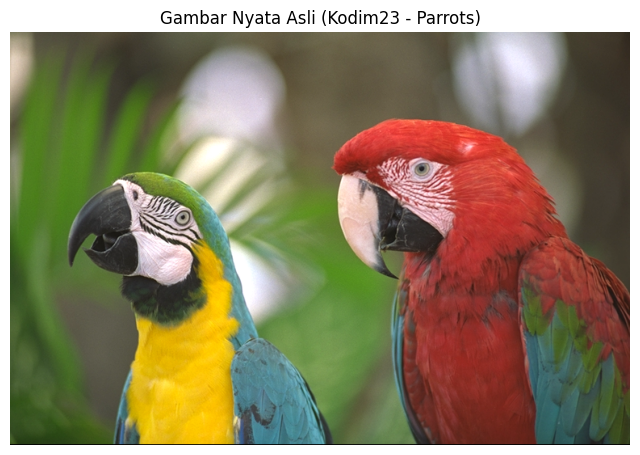


=== BLOK SINTETIS 8x8 UNTUK ANALISIS MATEMATIS ===
[[200 202 189 188  50  52  55  50]
 [201 200 190 185  51  50  53  52]
 [198 197 188 180  52  54  55  51]
 [205 203 195 182  50  51  52  50]
 [210 208 199 181  48  49  53  51]
 [212 211 202 185  50  52  51  50]
 [215 214 205 190  51  50  52  53]
 [218 217 208 192  52  51  50  51]]


In [1]:
# =====================================================================
# STEP 0: SETUP LIBRARIES & UNDUH GAMBAR NYATA (REAL IMAGE)
# =====================================================================
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import requests
from scipy.fftpack import dct, idct

# Fungsi untuk mengunduh gambar dari URL
def download_image(url, save_name):
    if not os.path.exists(save_name):
        try:
            response = requests.get(url)
            with open(save_name, 'wb') as f:
                f.write(response.content)
            print(f"Gambar {save_name} berhasil diunduh.")
        except Exception as e:
            print(f"Gagal mengunduh gambar: {e}")
    else:
        print(f"Gambar {save_name} sudah ada.")

# URL Gambar standar untuk DLC (Kodak dataset - lenna alternative)
# Kita gunakan gambar 'kodim23' (burung parrot) yang memiliki detail tajam dan warna cerah
url_real_img = "https://r0k.us/graphics/kodak/kodak/kodim23.png"
real_img_name = "parrots_original.png"

download_image(url_real_img, real_img_name)

# Matriks Kuantisasi Standar Luminance (Kecerahan) JPEG (IJG Standard)
Q_MATRIX = np.array([
    [16, 11, 10, 16, 24,  40,  51,  61],
    [12, 12, 14, 19, 26,  58,  60,  55],
    [14, 13, 16, 24, 40,  57,  69,  56],
    [14, 17, 22, 29, 51,  87,  80,  62],
    [18, 22, 37, 56, 68,  109, 103, 77],
    [24, 35, 55, 64, 81,  104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float32)

# Membuat blok gambar 8x8 piksel sintetis untuk analisis angka
# (Merepresentasikan area tepi tajam: Kiri terang, Kanan gelap)
blok_sintetis = np.array([
    [200, 202, 189, 188, 50, 52, 55, 50],
    [201, 200, 190, 185, 51, 50, 53, 52],
    [198, 197, 188, 180, 52, 54, 55, 51],
    [205, 203, 195, 182, 50, 51, 52, 50],
    [210, 208, 199, 181, 48, 49, 53, 51],
    [212, 211, 202, 185, 50, 52, 51, 50],
    [215, 214, 205, 190, 51, 50, 52, 53],
    [218, 217, 208, 192, 52, 51, 50, 51]
], dtype=np.float32)

# Menampilkan gambar nyata yang diunduh
img_real = cv2.imread(real_img_name)
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img_real, cv2.COLOR_BGR2RGB))
plt.title("Gambar Nyata Asli (Kodim23 - Parrots)")
plt.axis('off')
plt.show()

print("\n=== BLOK SINTETIS 8x8 UNTUK ANALISIS MATEMATIS ===")
print(blok_sintetis.astype(int))

## 2. Transformasi Frekuensi: 2D-DCT
Sebelum ditransformasikan, nilai piksel dikurangi dengan 128 (*Level Shifting*).
Hal ini bertujuan agar distribusi nilai berpusat di angka 0, yang mengoptimalkan akurasi komputasi bit koefisien.

Fungsi 2D-DCT dirumuskan secara matematis sebagai berikut:
$$F(u,v) = \frac{1}{4} C(u)C(v) \sum_{x=0}^{7} \sum_{y=0}^{7} f(x,y) \cos\left[\frac{(2x+1)u\pi}{16}\right] \cos\left[\frac{(2y+1)v\pi}{16}\right]$$

Jalankan blok kode di bawah ini untuk melihat bagaimana energi citra terpusat di area frekuensi rendah (koefisien kiri-atas) pada blok sintetis.

In [2]:
# =====================================================================
# STEP 1: LEVEL SHIFTING & FORWARD 2D-DCT (PADA BLOK SINTETIS)
# =====================================================================
def apply_2d_dct(block):
    # Transformasi DCT pada baris (T) kemudian pada kolom
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

# Eksekusi Level Shifting (-128)
blok_shifted = blok_sintetis - 128

# Eksekusi 2D-DCT
blok_dct = apply_2d_dct(blok_shifted)

np.set_printoptions(precision=1, suppress=True)
print("=== KOEFISIEN HASIL FORWARD 2D-DCT ===")
# Nilai pojok kiri atas (DC) sangat besar, kanan bawah (AC frekuensi tinggi) kecil
print(blok_dct)

=== KOEFISIEN HASIL FORWARD 2D-DCT ===
[[ -22.5  549.7   35.4 -166.9  -13.   108.3   -2.2  -93.3]
 [ -20.4  -24.2   -5.6    6.2    2.5    1.3   -5.    -2.1]
 [   7.8    4.3   -3.4   -3.     2.7    1.5   -2.5   -4.2]
 [   1.5    3.7    2.    -1.4   -1.4    0.9   -0.9   -1.1]
 [   1.5    4.4    0.9   -0.9   -1.     0.9   -0.4   -0.4]
 [   0.2   -1.9   -1.6    0.4   -0.2    0.5   -0.6   -1. ]
 [  -1.3   -2.5   -2.     3.1   -1.9   -0.6    0.4   -0.6]
 [  -0.8   -3.     1.4    0.4   -0.7    0.3   -1.1    0.7]]


## 3. Proses Kuantisasi Berdasarkan Quality Factor (QF)
Kuantisasi adalah tahap inti dari metode *Lossy Compression*. Koefisien DCT dibagi oleh komponen matriks kuantisasi ($Q$) yang telah diskalakan berdasarkan tingkat kualitas (*Quality Factor*), lalu dibulatkan ke bilangan bulat (*integer*).

$$F_{\text{quant}}(u,v) = \text{round}\left( \frac{F(u,v)}{Q(u,v)} \right)$$

* Jika **Quality Factor rendah (misal QF = 10)**, matriks pembagi $Q$ membesar secara masif, memaksa mayoritas nilai frekuensi tinggi menjadi **0**. Di sinilah informasi hilang.

In [3]:
# =====================================================================
# STEP 2: SKALA MATRIKS & PROSES KUANTISASI (PADA BLOK SINTETIS)
# =====================================================================
def get_quantized_block(dct_block, q_matrix, quality_factor=50):
    # Standar konversi penskalaan Quality Factor menurut Independent JPEG Group (IJG)
    if quality_factor < 50:
        scale = 5000 / quality_factor
    else:
        scale = 200 - 2 * quality_factor

    scaled_q = np.floor((q_matrix * scale + 50) / 100)
    scaled_q[scaled_q == 0] = 1 # Proteksi dari Zero Division Error

    # Proses Kuantisasi (Pembagian & Pembulatan Kompleks)
    quantized = np.round(dct_block / scaled_q)
    return quantized, scaled_q

# Lakukan kuantisasi dengan Quality Factor rendah (10) untuk memicu pembuangan data ekstrem
q_block, matriks_pembagi = get_quantized_block(blok_dct, Q_MATRIX, quality_factor=10)

print(f"=== MATRIKS PEMBAGI TER-SKALA (KUALITAS = 10) ===")
print(matriks_pembagi.astype(int))
print("\n=== HASIL MATRIKS SETELAH KUANTISASI (LOSS PHASE) ===")
print(q_block.astype(int)) # Perhatikan banyaknya angka 0

=== MATRIKS PEMBAGI TER-SKALA (KUALITAS = 10) ===
[[ 80  55  50  80 120 200 255 305]
 [ 60  60  70  95 130 290 300 275]
 [ 70  65  80 120 200 285 345 280]
 [ 70  85 110 145 255 435 400 310]
 [ 90 110 185 280 340 545 515 385]
 [120 175 275 320 405 520 565 460]
 [245 320 390 435 515 605 600 505]
 [360 460 475 490 560 500 515 495]]

=== HASIL MATRIKS SETELAH KUANTISASI (LOSS PHASE) ===
[[ 0 10  1 -2  0  1  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]]


## 4. Rekonstruksi Citra (Decoder Side)
Untuk mengembalikan data frekuensi ke bentuk gambar semula pada sisi pengguna (*penerima file*), dilakukan operasi kebalikannya:
1. **Dequantisasi:** $F_{\text{dequant}}(u,v) = F_{\text{quant}}(u,v) \times Q(u,v)$ (Nilai 0 tetap menjadi 0, nilai frekuensi tinggi asli hilang).
2. **2D-IDCT:** Transformasi balik frekuensi ke spasial.
3. **Inverse Level Shifting:** Menambahkan kembali nilai 128.

=== BLOK SINTETIS HASIL REKONSTRUKSI (QF=10) ===
[[227 183 213 183  55  35  79  44]
 [227 183 213 183  55  35  79  44]
 [227 183 213 183  55  35  79  44]
 [227 183 213 183  55  35  79  44]
 [227 183 213 183  55  35  79  44]
 [227 183 213 183  55  35  79  44]
 [227 183 213 183  55  35  79  44]
 [227 183 213 183  55  35  79  44]]


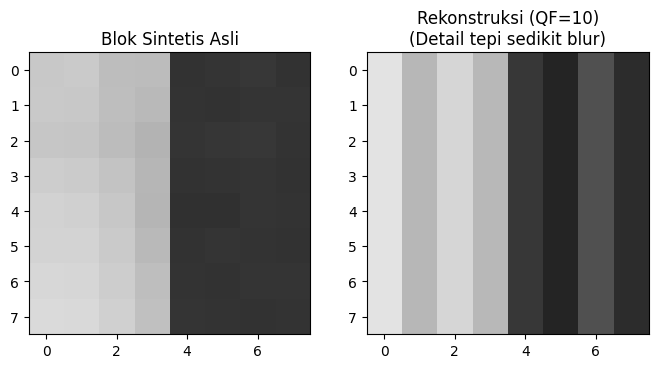

In [4]:
# =====================================================================
# STEP 3: DEQUANTISASI & INVERSE 2D-DCT (PADA BLOK SINTETIS)
# =====================================================================
def apply_2d_idct(dct_block):
    return idct(idct(dct_block.T, norm='ortho').T, norm='ortho')

# 1. Kalikan balik dengan matriks pembagi (Dequantisasi)
blok_dequant = q_block * matriks_pembagi

# 2. Aplikasikan Inverse DCT
blok_rekonstruksi_shifted = apply_2d_idct(blok_dequant)

# 3. Kembalikan pergeseran level (+128) dan clipping nilai piksel ke rentang murni [0, 255]
blok_final_sintetis = np.clip(blok_rekonstruksi_shifted + 128, 0, 255)

print("=== BLOK SINTETIS HASIL REKONSTRUKSI (QF=10) ===")
print(blok_final_sintetis.astype(int))

# Perbandingan visual pada blok sintetis
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(blok_sintetis, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Blok Sintetis Asli")
axes[1].imshow(blok_final_sintetis, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Rekonstruksi (QF=10)\n(Detail tepi sedikit blur)")
plt.show()

## 5. Implementasi pada Gambar Nyata (Real Image)
Sekarang kita akan menerapkan pipeline di atas pada gambar burung parrot yang telah diunduh.
Kita akan menggunakan fungsi OpenCV `cv2.imwrite` yang memiliki parameter kompresi JPEG terintegrasi untuk mensimulasikan proses encoder penuh.

Kita akan membandingkan:
1. **Lossless PNG:** Kualitas sempurna.
2. **JPEG Quality 90:** Kualitas tinggi, file kecil.
3. **JPEG Quality 10:** Kualitas sangat rendah, file sangat kecil, banyak artefak visual.

=== ANALISIS UKURAN FILE (KB) ===
Asli (Unduhan) : 544.53 KB
Lossless PNG   : 611.11 KB (Rasio: 0.89:1)
JPEG Quality 90: 75.52 KB (Rasio: 7.21:1)
JPEG Quality 10: 11.37 KB (Rasio: 47.91:1)


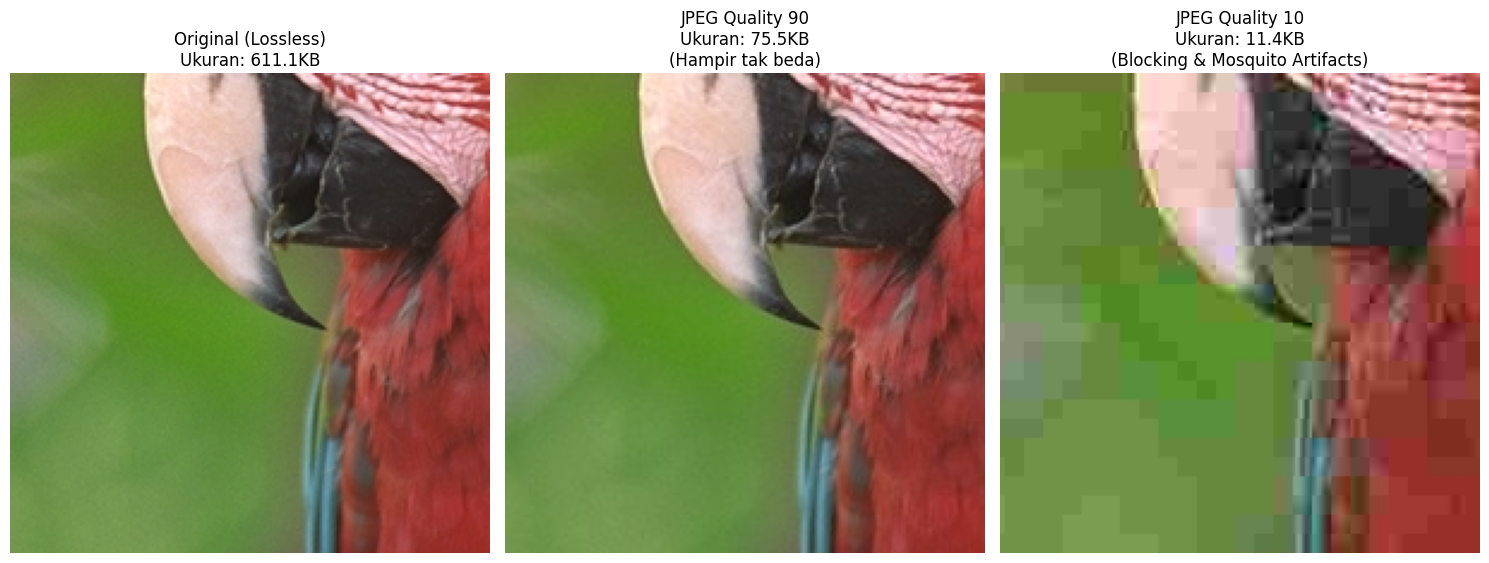


Perhatikan area 'JPEG Quality 10':
1. Blocking Artifact: Terlihat kotak-kotak ubin 8x8 piksel pada area bulu.
2. Mosquito Noise: Distorsi bintik kabur di sekitar tepi tajam paruh/mata.


In [5]:
# =====================================================================
# STEP 4: IMPLEMENTASI KOMPRESI PADA GAMBAR NYATA (REAL IMAGE)
# =====================================================================

# Load gambar asli
img_real = cv2.imread(real_img_name)

# 1. Simpan sebagai PNG (Lossless - untuk perbandingan)
name_png = "parrots_comp_lossless.png"
cv2.imwrite(name_png, img_real) # PNG default adalah lossless

# 2. Simpan sebagai JPEG Kualitas Tinggi (Quality 90)
name_jpg_high = "parrots_comp_q90.jpg"
cv2.imwrite(name_jpg_high, img_real, [int(cv2.IMWRITE_JPEG_QUALITY), 90])

# 3. Simpan sebagai JPEG Kualitas Sangat Rendah (Quality 10)
name_jpg_low = "parrots_comp_q10.jpg"
cv2.imwrite(name_jpg_low, img_real, [int(cv2.IMWRITE_JPEG_QUALITY), 10])

# --- Analisis Ukuran File ---
size_org = os.path.getsize(real_img_name) / 1024
size_png = os.path.getsize(name_png) / 1024
size_q90 = os.path.getsize(name_jpg_high) / 1024
size_q10 = os.path.getsize(name_jpg_low) / 1024

print("=== ANALISIS UKURAN FILE (KB) ===")
print(f"Asli (Unduhan) : {size_org:.2f} KB")
print(f"Lossless PNG   : {size_png:.2f} KB (Rasio: {size_org/size_png:.2f}:1)")
print(f"JPEG Quality 90: {size_q90:.2f} KB (Rasio: {size_org/size_q90:.2f}:1)")
print(f"JPEG Quality 10: {size_q10:.2f} KB (Rasio: {size_org/size_q10:.2f}:1)")

# --- Visualisasi Perbandingan Visual (Crop Area Tajam) ---
# Kita lakukan cropping pada area bulu/mata burung untuk melihat detail
img_high = cv2.imread(name_jpg_high)
img_low = cv2.imread(name_jpg_low)

# Tentukan koordinat crop [y1:y2, x1:x2] (area mata burung)
crop_y1, crop_y2, crop_x1, crop_x2 = 200, 400, 350, 550
crop_org = img_real[crop_y1:crop_y2, crop_x1:crop_x2]
crop_high = img_high[crop_y1:crop_y2, crop_x1:crop_x2]
crop_low = img_low[crop_y1:crop_y2, crop_x1:crop_x2]

# Fungsi bantu konversi warna untuk matplotlib
def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
axes[0].imshow(bgr2rgb(crop_org))
axes[0].set_title(f"Original (Lossless)\nUkuran: {size_png:.1f}KB")
axes[0].axis('off')

axes[1].imshow(bgr2rgb(crop_high))
axes[1].set_title(f"JPEG Quality 90\nUkuran: {size_q90:.1f}KB\n(Hampir tak beda)")
axes[1].axis('off')

axes[2].imshow(bgr2rgb(crop_low))
axes[2].set_title(f"JPEG Quality 10\nUkuran: {size_q10:.1f}KB\n(Blocking & Mosquito Artifacts)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\nPerhatikan area 'JPEG Quality 10':")
print("1. Blocking Artifact: Terlihat kotak-kotak ubin 8x8 piksel pada area bulu.")
print("2. Mosquito Noise: Distorsi bintik kabur di sekitar tepi tajam paruh/mata.")

## 6. Lembar Tugas Mandiri Praktikum (Wajib Dikumpulkan)


1. **Evaluasi Objektif Gambar Nyata:** Gunakan fungsi `evaluate_metrics(original, reconstructed)` yang ada di Cell 10 praktikum sebelumnya (atau buat ulang di cell baru). Hitunglah nilai **MSE** dan **PSNR (dB)** antara:
   - Gambar Asli (`img_real`) vs JPEG Kualitas 90 (`img_high`).
   - Gambar Asli (`img_real`) vs JPEG Kualitas 10 (`img_low`).
   *Catatan: Pastikan dimensi gambar sama sebelum dihitung.*

In [8]:
print("Dimensi img_real :", img_real.shape)
print("Dimensi img_high :", img_high.shape)
print("Dimensi img_low  :", img_low.shape)

Dimensi img_real : (512, 768, 3)
Dimensi img_high : (512, 768, 3)
Dimensi img_low  : (512, 768, 3)


In [6]:
def evaluate_metrics(original, reconstructed):
    # Menghitung MSE
    mse = np.mean((original.astype(np.float64) - reconstructed.astype(np.float64)) ** 2)

    if mse == 0:
        return 0, float('inf') # Jika gambarnya identik sempurna

    # Menghitung PSNR
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))

    return mse, psnr

# 1. Hitung untuk kualitas tinggi (90)
mse_high, psnr_high = evaluate_metrics(img_real, img_high)
print(f"Kualitas 90 -> MSE: {mse_high:.4f}, PSNR: {psnr_high:.2f} dB")

# 2. Hitung untuk kualitas rendah (10)
mse_low, psnr_low = evaluate_metrics(img_real, img_low)
print(f"Kualitas 10 -> MSE: {mse_low:.4f}, PSNR: {psnr_low:.2f} dB")

Kualitas 90 -> MSE: 7.0627, PSNR: 39.64 dB
Kualitas 10 -> MSE: 84.2826, PSNR: 28.87 dB


2. **Analisis Tren QF vs PSNR:** Lakukan looping untuk menyimpan gambar nyata asli tadi ke format JPEG dengan `Quality Factor = [10, 30, 50, 70, 90]`. Hitung PSNR untuk setiap hasil kompresi tersebut.

In [14]:
# Ambil dimensi target dari gambar asli untuk antisipasi
h_target, w_target = img_real.shape[:2]

# Daftar Quality Factor yang diuji
quality_factors = [10, 30, 50, 70, 90]
psnr_results = []

# Looping Kompresi dan Perhitungan
for qf in quality_factors:
    # 1. Kompresi gambar asli ke memori dengan QF tertentu
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), qf]
    _, encoded_img = cv2.imencode('.jpg', img_real, encode_param)

    # 2. Dekompresi kembali untuk mendapatkan gambar hasil kompresi
    decoded_img = cv2.imdecode(encoded_img, cv2.IMREAD_COLOR)

    # 3. Pastikan dimensi sama persis
    decoded_img = cv2.resize(decoded_img, (w_target, h_target))

    # 4. Hitung metrik dan simpan hasil PSNR
    _, psnr = evaluate_metrics(img_real, decoded_img)
    psnr_results.append(psnr)

    print(f"Quality Factor {qf} -> PSNR: {psnr:.2f} dB")

Quality Factor 10 -> PSNR: 28.87 dB
Quality Factor 30 -> PSNR: 33.38 dB
Quality Factor 50 -> PSNR: 35.08 dB
Quality Factor 70 -> PSNR: 36.63 dB
Quality Factor 90 -> PSNR: 39.64 dB


3. **Grafik & Kesimpulan:** Plot grafik garis (menggunakan `plt.plot()`) hubungan antara **Quality Factor (Sumbu X)** vs **PSNR dB (Sumbu Y)**. Tulislah kesimpulan di laporan Anda: Mengapa nilai PSNR tidak naik secara linear (lurus) saat Quality Factor dinaikkan, melainkan cenderung melambat (saturasi) di kualitas tinggi?

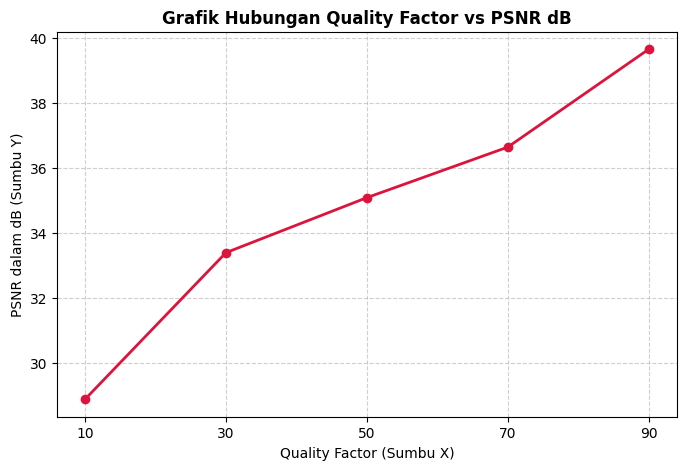

In [15]:
# Plot Grafik Garis
plt.figure(figsize=(8, 5))
plt.plot(quality_factors, psnr_results, marker='o', color='crimson', linestyle='-', linewidth=2)
plt.title("Grafik Hubungan Quality Factor vs PSNR dB", fontsize=12, fontweight='bold')
plt.xlabel("Quality Factor (Sumbu X)", fontsize=10)
plt.ylabel("PSNR dalam dB (Sumbu Y)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(quality_factors)
plt.show()

KESIMPULAN:
Berdasarkan grafik pengujian, hubungan antara Quality Factor (QF) JPEG dan PSNR terbukti tidak linear melainkan berbentuk logaritmik (concave). Kenaikan PSNR sangat signifikan pada rentang QF rendah hingga menengah (QF 10 ke 50) karena pemulihan komponen utama gambar berjalan masif.

Namun, grafik mengalami saturasi (melambat) pada rentang kualitas tinggi (QF 70 ke 90). Hal ini disebabkan oleh sifat matematis rumus PSNR yang menggunakan skala logaritmik desibel (dB) serta karakteristik algoritma kuantisasi JPEG; di mana penambahan nilai QF di fase akhir hanya mengembalikan informasi detail frekuensi sangat tinggi (noise/tekstur mikro) yang tidak sensitif bagi mata manusia (Psychovisual Redundancy) dan memberikan pengaruh penurunan MSE (Mean Squared Error) yang sangat kecil.